In [8]:
import networkx as nx
import json
import random
import matplotlib.pyplot as plt

In [9]:
with open("ntu_synbullying_small_with_id.json", "r") as f:
  data = json.load(f)

In [10]:
all_convos = [
    convo
    for conversations in data.values()
    for convo in conversations
]

all_messages = [
    msg
    for conversations in data.values()
    for convo in conversations
    for msg in convo['messages']
]

all_ids = set(text["user_id"] for text in all_messages)
all_ids

{0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 16,
 17,
 18,
 19,
 20,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 43,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 98,
 99}

In [11]:
len(all_convos)

160

In [12]:
G = nx.Graph()

for idx, convo in enumerate(all_convos[:10]):
  user_ids = set((text["user_id"], text["speaker"]) for text in convo['messages'])
  convo_id = "C" + str(idx)
  for id, role in user_ids:
    G.add_edge(id, convo_id, role=role)

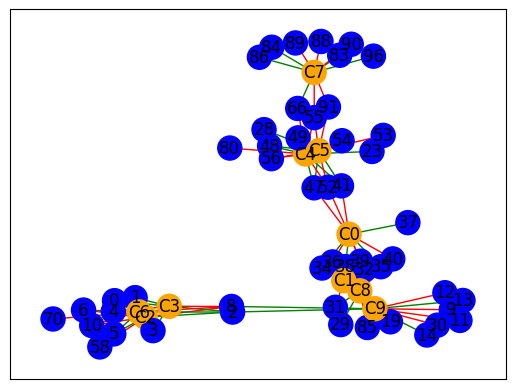

In [13]:
pos = nx.spring_layout(G)
node_colors = ["orange" if isinstance(node, str) else "blue" for node in G.nodes()]
edge_colors = ["red" if "B" in attr['role'] else "green" for _, _, attr in G.edges(data=True)]
nx.draw_networkx(G, pos=pos, node_color=node_colors, edge_color=edge_colors)

modules.json:   0%|          | 0.00/573 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/18.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

3_Dense/model.safetensors: reconstructing file:   0%|          |  0.00B / 9.44MB            

3_Dense/model.safetensors: downloading bytes:           |  0.00B            

100%|██████████| 450/450 [02:54<00:00,  2.57it/s]


Epoch 1: Train loss = 0.5139, Val loss = 0.4558, Best Val Loss = inf
Epoch 2: Train loss = 0.4437, Val loss = 0.4300, Best Val Loss = 0.4558
Epoch 3: Train loss = 0.4264, Val loss = 0.4187, Best Val Loss = 0.4300
Epoch 4: Train loss = 0.4149, Val loss = 0.4152, Best Val Loss = 0.4187
Epoch 5: Train loss = 0.4069, Val loss = 0.4051, Best Val Loss = 0.4152
Epoch 6: Train loss = 0.3989, Val loss = 0.4002, Best Val Loss = 0.4051
Epoch 7: Train loss = 0.3942, Val loss = 0.3965, Best Val Loss = 0.4002
Epoch 8: Train loss = 0.3878, Val loss = 0.3918, Best Val Loss = 0.3965
Epoch 9: Train loss = 0.3821, Val loss = 0.3891, Best Val Loss = 0.3918
Epoch 10: Train loss = 0.3758, Val loss = 0.3841, Best Val Loss = 0.3891
Epoch 11: Train loss = 0.3715, Val loss = 0.3817, Best Val Loss = 0.3841
Epoch 12: Train loss = 0.3680, Val loss = 0.3802, Best Val Loss = 0.3817
Epoch 13: Train loss = 0.3641, Val loss = 0.3783, Best Val Loss = 0.3802
Epoch 14: Train loss = 0.3595, Val loss = 0.3760, Best Val Loss

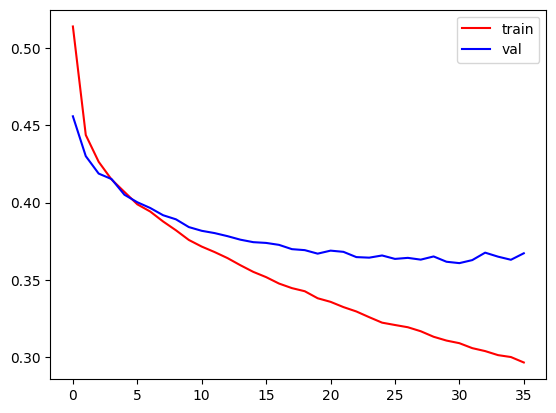

In [14]:
import json
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

embeddinggemma = SentenceTransformer("google/embeddinggemma-300m")

model = nn.Sequential(
    nn.Linear(768, 128),
    nn.Dropout(),
    nn.ReLU(),
    nn.Linear(128, 1)
)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters())
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

EPOCHS = 200
EARLY_STOP = 5

def layer_1_embedding_gemma(input_file, output_file, batch_size=32):
    with open(input_file, "r") as f:
        data = json.load(f)

    all_msg = [
        msg
        for conversations in data.values()
        for convo in conversations
        for msg in convo['messages']
    ]

    embeddings = []

    for i in tqdm(range(0, len(all_msg), batch_size)):
        batch = all_msg[i:i + batch_size]

        texts = [msg['text'] for msg in batch]

        document_embeddings = embeddinggemma.encode_document(texts)
        embeddings.append(document_embeddings)

    embeddings_np = np.concat(embeddings)
    np.save(output_file, embeddings_np)

    X = torch.from_numpy(embeddings_np).to(device)
    y = torch.Tensor([1 if "BULLY" in msg['speaker'] else 0 for msg in all_msg]).to(device)

    dataset = TensorDataset(X, y)
    train_dataset, val_dataset = random_split(dataset, [0.8, 0.2])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    train_losses, val_losses = [], []
    best_train_loss, best_val_loss = float("inf"), float("inf")
    counter = 0
    for epoch in range(EPOCHS):
      model.train()
      train_loss = 0.0
      for X_train, y_train in train_loader:
        out = model(X_train)
        loss = criterion(out.squeeze(), y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_train.size(0)

      train_loss /= len(train_loader.dataset)

      model.eval()
      val_loss = 0.0
      with torch.no_grad():
        for X_val, y_val in val_loader:
          out = model(X_val)
          loss = criterion(out.squeeze(), y_val)

          val_loss += loss.item() * X_val.size(0)

      val_loss /= len(val_loader.dataset)

      print(f"Epoch {epoch+1}: Train loss = {train_loss:.4f}, Val loss = {val_loss:.4f}, Best Val Loss = {best_val_loss:.4f}")
      train_losses.append(train_loss)
      val_losses.append(val_loss)

      if val_loss >= best_val_loss:
        counter = counter + 1
      else:
        best_val_loss = val_loss
        counter = 0

      if counter == EARLY_STOP:
        break

    plt.plot(train_losses, "r")
    plt.plot(val_losses, "b")
    plt.legend(["train", "val"])

    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for X_val, y_val in val_loader:
          out = model(X_val)
          out = nn.functional.sigmoid(out)
          pred = out.round().detach().cpu().numpy()
          labels = y_val.detach().cpu().numpy()

          y_pred.append(pred)
          y_true.append(labels)

    y_pred = np.concat(y_pred)
    y_true = np.concat(y_true)

    print(classification_report(y_true, y_pred, target_names=["Normal", "Bully"], digits=4))
# layer_1_embedding_gemma("ntu_synbullying_small.json", "ntu_synbullying_small_embeddings.npy", 128)
layer_1_embedding_gemma("ntu_synbullying_with_id.json", "nus_synbullying_embeddings.npy", 128)

In [15]:
!uv pip install node2vec

Using Python 3.12.13 environment at: /usr
Resolved 9 packages in 481ms
Prepared 3 packages in 897ms
Uninstalled 1 package in 38ms
Installed 3 packages in 19ms
 + gensim==4.4.0
 + node2vec==0.5.0
 - numpy==2.0.2
 + numpy==1.26.4


Computing transition probabilities:   0%|          | 0/3010 [00:00<?, ?it/s]

100%|██████████| 450/450 [03:00<00:00,  2.49it/s]


Epoch 1: Train loss = 0.4596, Val loss = 0.3690, Best Val Loss = inf
Epoch 2: Train loss = 0.3352, Val loss = 0.2894, Best Val Loss = 0.3690
Epoch 3: Train loss = 0.2680, Val loss = 0.2329, Best Val Loss = 0.2894
Epoch 4: Train loss = 0.2280, Val loss = 0.1958, Best Val Loss = 0.2329
Epoch 5: Train loss = 0.1983, Val loss = 0.1707, Best Val Loss = 0.1958
Epoch 6: Train loss = 0.1774, Val loss = 0.1562, Best Val Loss = 0.1707
Epoch 7: Train loss = 0.1607, Val loss = 0.1448, Best Val Loss = 0.1562
Epoch 8: Train loss = 0.1492, Val loss = 0.1365, Best Val Loss = 0.1448
Epoch 9: Train loss = 0.1400, Val loss = 0.1277, Best Val Loss = 0.1365
Epoch 10: Train loss = 0.1328, Val loss = 0.1238, Best Val Loss = 0.1277
Epoch 11: Train loss = 0.1257, Val loss = 0.1197, Best Val Loss = 0.1238
Epoch 12: Train loss = 0.1199, Val loss = 0.1149, Best Val Loss = 0.1197
Epoch 13: Train loss = 0.1117, Val loss = 0.1148, Best Val Loss = 0.1149
Epoch 14: Train loss = 0.1082, Val loss = 0.1097, Best Val Loss

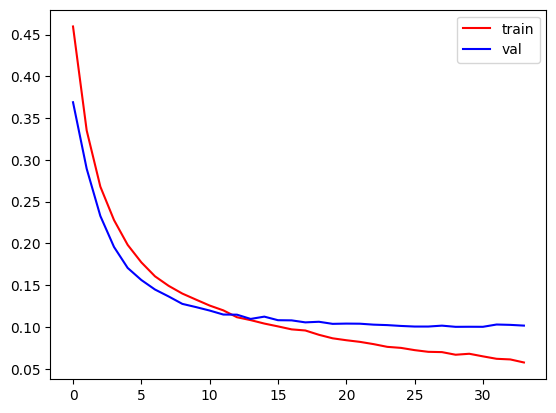

In [17]:
import json
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from node2vec import Node2Vec

model = nn.Sequential(
    nn.Linear(768+128, 128),
    nn.Dropout(),
    nn.ReLU(),
    nn.Linear(128, 1)
)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters())
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

EPOCHS = 200
EARLY_STOP = 5

def layer_2(input_file, output_file, batch_size=32):
    with open(input_file, "r") as f:
        data = json.load(f)

    all_msg = [
        msg
        for conversations in data.values()
        for convo in conversations
        for msg in convo['messages']
    ]

    all_convos = [
        convo
        for conversations in data.values()
        for convo in conversations
    ]

    G = nx.Graph()

    for idx, convo in enumerate(all_convos):
      user_ids = set((text["user_id"], text["speaker"]) for text in convo['messages'])
      convo_id = "C" + str(idx)
      for id, role in user_ids:
        G.add_edge(id, convo_id, role=role)

    node2vec = Node2Vec(G)
    node2vec_model = node2vec.fit()

    embeddings = []

    for i in tqdm(range(0, len(all_msg), batch_size)):
        batch = all_msg[i:i + batch_size]

        texts = [msg['text'] for msg in batch]
        node2vec_emb = [node2vec_model.wv.get_vector(int(msg['user_id'])) for msg in batch]
        node2vec_emb = np.array(node2vec_emb)
        document_embeddings = embeddinggemma.encode_document(texts)
        document_embeddings = np.concat((document_embeddings, node2vec_emb), axis=-1)
        embeddings.append(document_embeddings)

    embeddings_np = np.concat(embeddings)

    X = torch.from_numpy(embeddings_np).to(device)
    y = torch.Tensor([1 if "BULLY" in msg['speaker'] else 0 for msg in all_msg]).to(device)

    dataset = TensorDataset(X, y)
    train_dataset, val_dataset = random_split(dataset, [0.8, 0.2])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    train_losses, val_losses = [], []
    best_train_loss, best_val_loss = float("inf"), float("inf")
    counter = 0
    for epoch in range(EPOCHS):
      model.train()
      train_loss = 0.0
      for X_train, y_train in train_loader:
        out = model(X_train)
        loss = criterion(out.squeeze(), y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_train.size(0)

      train_loss /= len(train_loader.dataset)

      model.eval()
      val_loss = 0.0
      with torch.no_grad():
        for X_val, y_val in val_loader:
          out = model(X_val)
          loss = criterion(out.squeeze(), y_val)

          val_loss += loss.item() * X_val.size(0)

      val_loss /= len(val_loader.dataset)

      print(f"Epoch {epoch+1}: Train loss = {train_loss:.4f}, Val loss = {val_loss:.4f}, Best Val Loss = {best_val_loss:.4f}")
      train_losses.append(train_loss)
      val_losses.append(val_loss)

      if val_loss >= best_val_loss:
        counter = counter + 1
      else:
        best_val_loss = val_loss
        counter = 0

      if counter == EARLY_STOP:
        break

    torch.save(model.state_dict(), output_file)

    plt.plot(train_losses, "r")
    plt.plot(val_losses, "b")
    plt.legend(["train", "val"])
    plt.savefig("train_val_loss_layer2.png")

    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for X_val, y_val in val_loader:
          out = model(X_val)
          out = nn.functional.sigmoid(out)
          pred = out.round().detach().cpu().numpy()
          labels = y_val.detach().cpu().numpy()

          y_pred.append(pred)
          y_true.append(labels)

    y_pred = np.concat(y_pred)
    y_true = np.concat(y_true)

    print(classification_report(y_true, y_pred, target_names=["Normal", "Bully"], digits=4))

layer_2("ntu_synbullying_with_id.json", "ntu_layer2_classifier_head.pth", 128)

In [18]:
import networkx as nx
from node2vec import Node2Vec
import json

def node2vec_embeddings(input_file, output_file):
    with open(input_file, "r") as f:
        data = json.load(f)

    all_convos = [
        convo
        for conversations in data.values()
        for convo in conversations
    ]

    G = nx.Graph()

    for idx, convo in enumerate(all_convos):
      user_ids = set((text["user_id"], text["speaker"]) for text in convo['messages'])
      convo_id = "C" + str(idx)
      for id, role in user_ids:
        G.add_edge(id, convo_id, role=role)

    node2vec = Node2Vec(G)
    node2vec_model = node2vec.fit()

    node2vec_model.wv.save_word2vec_format(output_file)

if __name__ == "__main__":
    node2vec_embeddings(
       "ntu_synbullying_with_id.json",
       "ntu_node2vec_embeddings.emb"
    )

    # node2vec_embeddings(
    #    "data/nus_synbullying_with_id.json",
    #    "data/nus_node2vec_embeddings.emb"
    # )

Computing transition probabilities:   0%|          | 0/3010 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:11<00:00,  1.16s/it]


In [32]:
import torch
import torch.nn as nn
import numpy as np
from sentence_transformers import SentenceTransformer
from gensim.models import KeyedVectors

class Layer2:
    def __init__(self,
                 classifier_head_model_path,
                 node2vec_embedding_path,
                 text_embedding_model="google/embeddinggemma-300m",
                ):
        self.classifier_head = nn.Sequential(
            nn.Linear(768 + 128, 128),
            nn.Dropout(),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        self.classifier_head_model_path = classifier_head_model_path
        self.classifier_head.load_state_dict(torch.load(classifier_head_model_path, weights_only=True))
        self.classifier_head.eval()
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.classifier_head.to(self.device)

        self.embedding_gemma = SentenceTransformer(text_embedding_model)
        self.embedding_gemma.eval()
        self.embedding_gemma.to(self.device)

        self.node2vec_wv = KeyedVectors.load_word2vec_format(node2vec_embedding_path)

    def predict(self, message: str, user_id: int):

        text_emb = self.embedding_gemma.encode_query(message)
        user_emb = self.node2vec_wv.get_vector(user_id)

        combined_emb = np.concat((text_emb, user_emb), axis=0)
        combined_emb_tensor = torch.from_numpy(combined_emb).to(self.device)

        with torch.no_grad():
            out = self.classifier_head(combined_emb_tensor)
            out = nn.functional.sigmoid(out)
            pred = out.detach().cpu().numpy()[0]

        return {
            "layer": 2,
            "status": "bully" if pred >= 0.5 else "normal",
            "raw_label": "bully" if pred >= 0.5 else "normal",
            "normal_score": round(float(1-pred), 4),
            "bully_score": round(float(pred), 4),
            "model_dir": self.classifier_head_model_path,
        }

if __name__ == "__main__":
    layer2 = Layer2(
        "ntu_layer2_classifier_head.pth",
        "ntu_node2vec_embeddings.emb"
        )
    print(layer2.predict("whatever lah. saw him crying last week when everyone was at the event. super embarrassing.", 810))

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

(896,)
0.9961319
{'layer': 2, 'status': 'bully', 'raw_label': 'bully', 'normal_score': 0.0039, 'bully_score': 0.9961, 'model_dir': 'ntu_layer2_classifier_head.pth'}
